# Kernel Events Validation Technical Report

## Methods

Timing accuracy of the action LEDs was evaluated using software logging and oscilloscope measurements after refactoring the button handling logic to use kernel events. The purpose of this analysis was to verify that the refactor did not affect the timing behavior of the action LEDs.

For the logging-based analysis, timestamps were recorded each time the action LEDs toggled. The elapsed time between successive toggles was measured using system tick timestamps and converted to nanoseconds. These durations were logged as action toggle periods. Terminal output for three operating conditions (1 Hz, 2 Hz default, and 5 Hz) was saved to text files and parsed in a Jupyter notebook using pandas. Because each toggle corresponds to half of a full signal period, the measured durations were used to compute the corresponding LED frequency.

Because the timestamp measurements are quantized to the system clock tick, the effective resolution of the measurements is limited to one tick. As in previous analyses, when repeated measurements produced identical values, the 95% confidence interval was estimated as plus or minus half of one system tick in the period domain.

To independently verify the logging results, oscilloscope measurements were also performed. The action LED output signal was connected to a digital oscilloscope through the accessible GPIO header pins on the development board. The oscilloscope measurement tools were used to determine the signal period and frequency across multiple cycles for representative operating conditions. These measurements were used to confirm that the LED timing matched the nominal specifications.

## Results

In [1]:
# import CSV files and read "action" data
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def read_type(fname, keyword):
    df = pd.read_csv(fname, sep=r"\s+", header=None, usecols=[0,3,7],
                     names=['timestamp','type','toggle duration (ns)'],
                     engine="python")
    df = df[df['type'].astype(str).str.contains(keyword, case=False, na=False)].copy()
    df['frequency (Hz)'] = 1e9 / (2 * df['toggle duration (ns)'])
    return df

log_1Hz_action = read_type('kernel_1Hz.txt', 'action')
log_5Hz_action = read_type('kernel_5Hz.txt', 'action')
log_2Hz_action = read_type('thread_2Hz_HB.txt', 'action')

In [2]:
summary_action = pd.DataFrame({
    '1 Hz (action)': log_1Hz_action['frequency (Hz)'].describe(),
    '2 Hz (action)': log_2Hz_action['frequency (Hz)'].describe(),
    '5 Hz (action)': log_5Hz_action['frequency (Hz)'].describe()
})

from IPython.display import display
display(summary_action)

,1 Hz (action),2 Hz (action),5 Hz (action)
count,290.000000,400.000000,5.000000e+02
mean,0.999988,1.999976,4.999695e+00
std,0.000024,0.000073,2.500917e-08
min,0.999939,1.999756,4.999695e+00
25%,1.000000,2.000000,4.999695e+00
50%,1.000000,2.000000,4.999695e+00
75%,1.000000,2.000000,4.999695e+00
max,1.000000,2.000000,4.999695e+00


In [4]:
# 95% CI
ticks_per_sec = 1e3
tick_s = 1 / ticks_per_sec
half_tick_ms = (tick_s / 2) * 1000

def resolution_ci_ms(mean_ms, decimals=3):
    return (round(mean_ms - half_tick_ms, decimals),
            round(mean_ms + half_tick_ms, decimals))

# convert frequencies to periods
period_1 = 1000 / log_1Hz_action["frequency (Hz)"].mean()
period_2 = 1000 / log_2Hz_action["frequency (Hz)"].mean()
period_5 = 1000 / log_5Hz_action["frequency (Hz)"].mean()

freq_1 = log_1Hz_action["frequency (Hz)"].mean()
freq_2 = log_2Hz_action["frequency (Hz)"].mean()
freq_5 = log_5Hz_action["frequency (Hz)"].mean()

ci_table = pd.DataFrame({
    "1 Hz": [
        1000.0,
        period_1,
        resolution_ci_ms(period_1),
        period_1 - 1000.0
    ],
    "2 Hz": [
        500.0,
        period_2,
        resolution_ci_ms(period_2),
        period_2 - 500.0
    ],
    "5 Hz": [
        200.0,
        period_5,
        resolution_ci_ms(period_5),
        period_5 - 200.0
    ]
}, index=["Nominal Period (ms)", "Measured mean (ms)", "95% CI (ms)", "Error vs nominal (ms)"])

display(ci_table)

,1 Hz,2 Hz,5 Hz
Nominal Period (ms),1000.0,500.0,200.0
Measured mean (ms),1000.012206,500.006103,200.012207
95% CI (ms),"(999.512, 1000.512)","(499.506, 500.506)","(199.512, 200.512)"
Error vs nominal (ms),0.012206,0.006103,0.012207


## Oscilloscope Measurements

### 1 Hz Oscilloscope Output

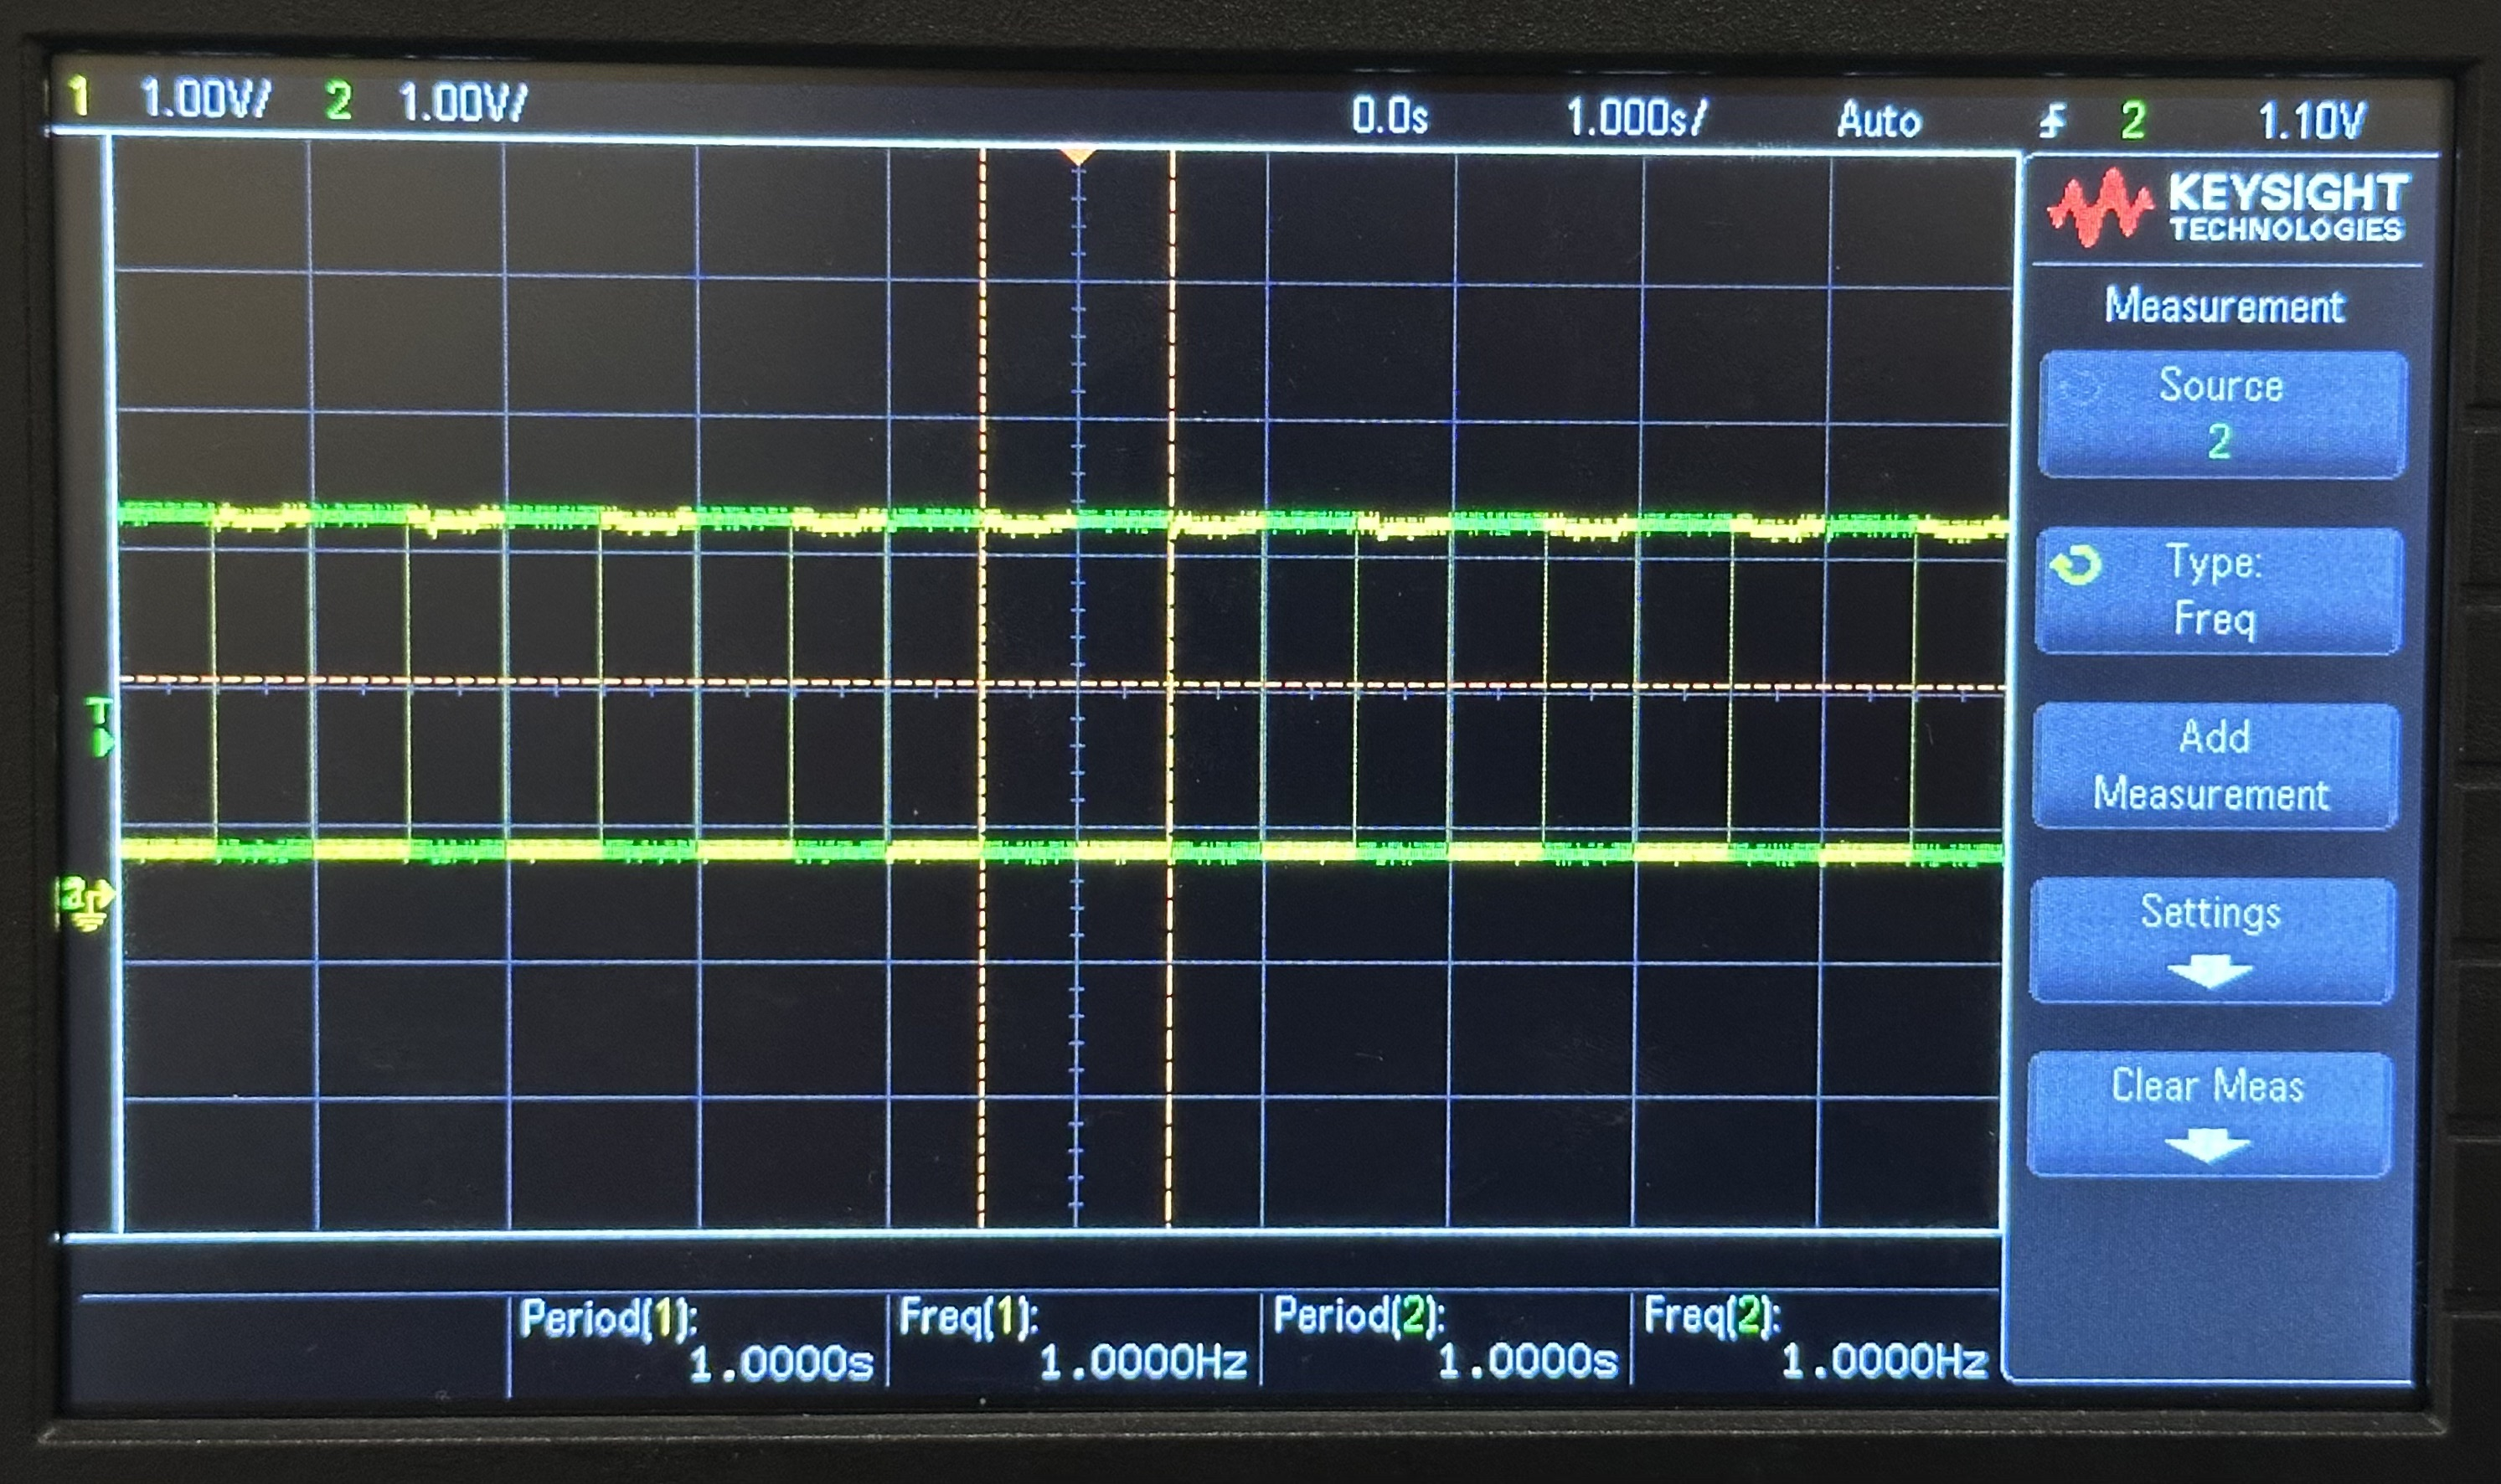

In [5]:
from IPython.display import Image, display

display(Image("1Hz.jpeg"))  

In [10]:
import pandas as pd

scope_1 = pd.DataFrame({
    "Condition": ["Action timing (1 Hz)"],
    "Measured Period (ms)": [1000.0], 
    "Nominal Period (ms)":  [1000.0],
    "Measured Frequency (Hz)": [1.0], 
    "Nominal Frequency (Hz)":  [1.0],
    "Resolution (ms)":      [0.1]    
})

scope_1["Half Resolution (ms)"] = scope_1["Resolution (ms)"] / 2

scope_1["95% CI Period (ms)"] = scope_1.apply(
    lambda row: (
        round(row["Measured Period (ms)"] - row["Half Resolution (ms)"], 3),
        round(row["Measured Period (ms)"] + row["Half Resolution (ms)"], 3)
    ),
    axis=1
)

scope_1["95% CI Frequency (Hz)"] = scope_1.apply(
    lambda row: (
        round(1000 / (row["Measured Period (ms)"] + row["Half Resolution (ms)"]), 4),
        round(1000 / (row["Measured Period (ms)"] - row["Half Resolution (ms)"]), 4)
    ),
    axis=1
)

scope_1["Error vs Nominal Period (ms)"] = (
    scope_1["Measured Period (ms)"] - scope_1["Nominal Period (ms)"]
)

scope_1["Error vs Nominal Frequency (Hz)"] = (
    scope_1["Measured Frequency (Hz)"] - scope_1["Nominal Frequency (Hz)"]
)

scope_1

,Condition,Measured Period (ms),Nominal Period (ms),Measured Frequency (Hz),Nominal Frequency (Hz),Resolution (ms),Half Resolution (ms),95% CI Period (ms),95% CI Frequency (Hz),Error vs Nominal Period (ms),Error vs Nominal Frequency (Hz)
0,Action timing (1 Hz),1000.0,1000.0,1.0,1.0,0.1,0.05,"(999.95, 1000.05)","(1.0, 1.0001)",0.0,0.0


### 5 Hz Oscilloscope Output

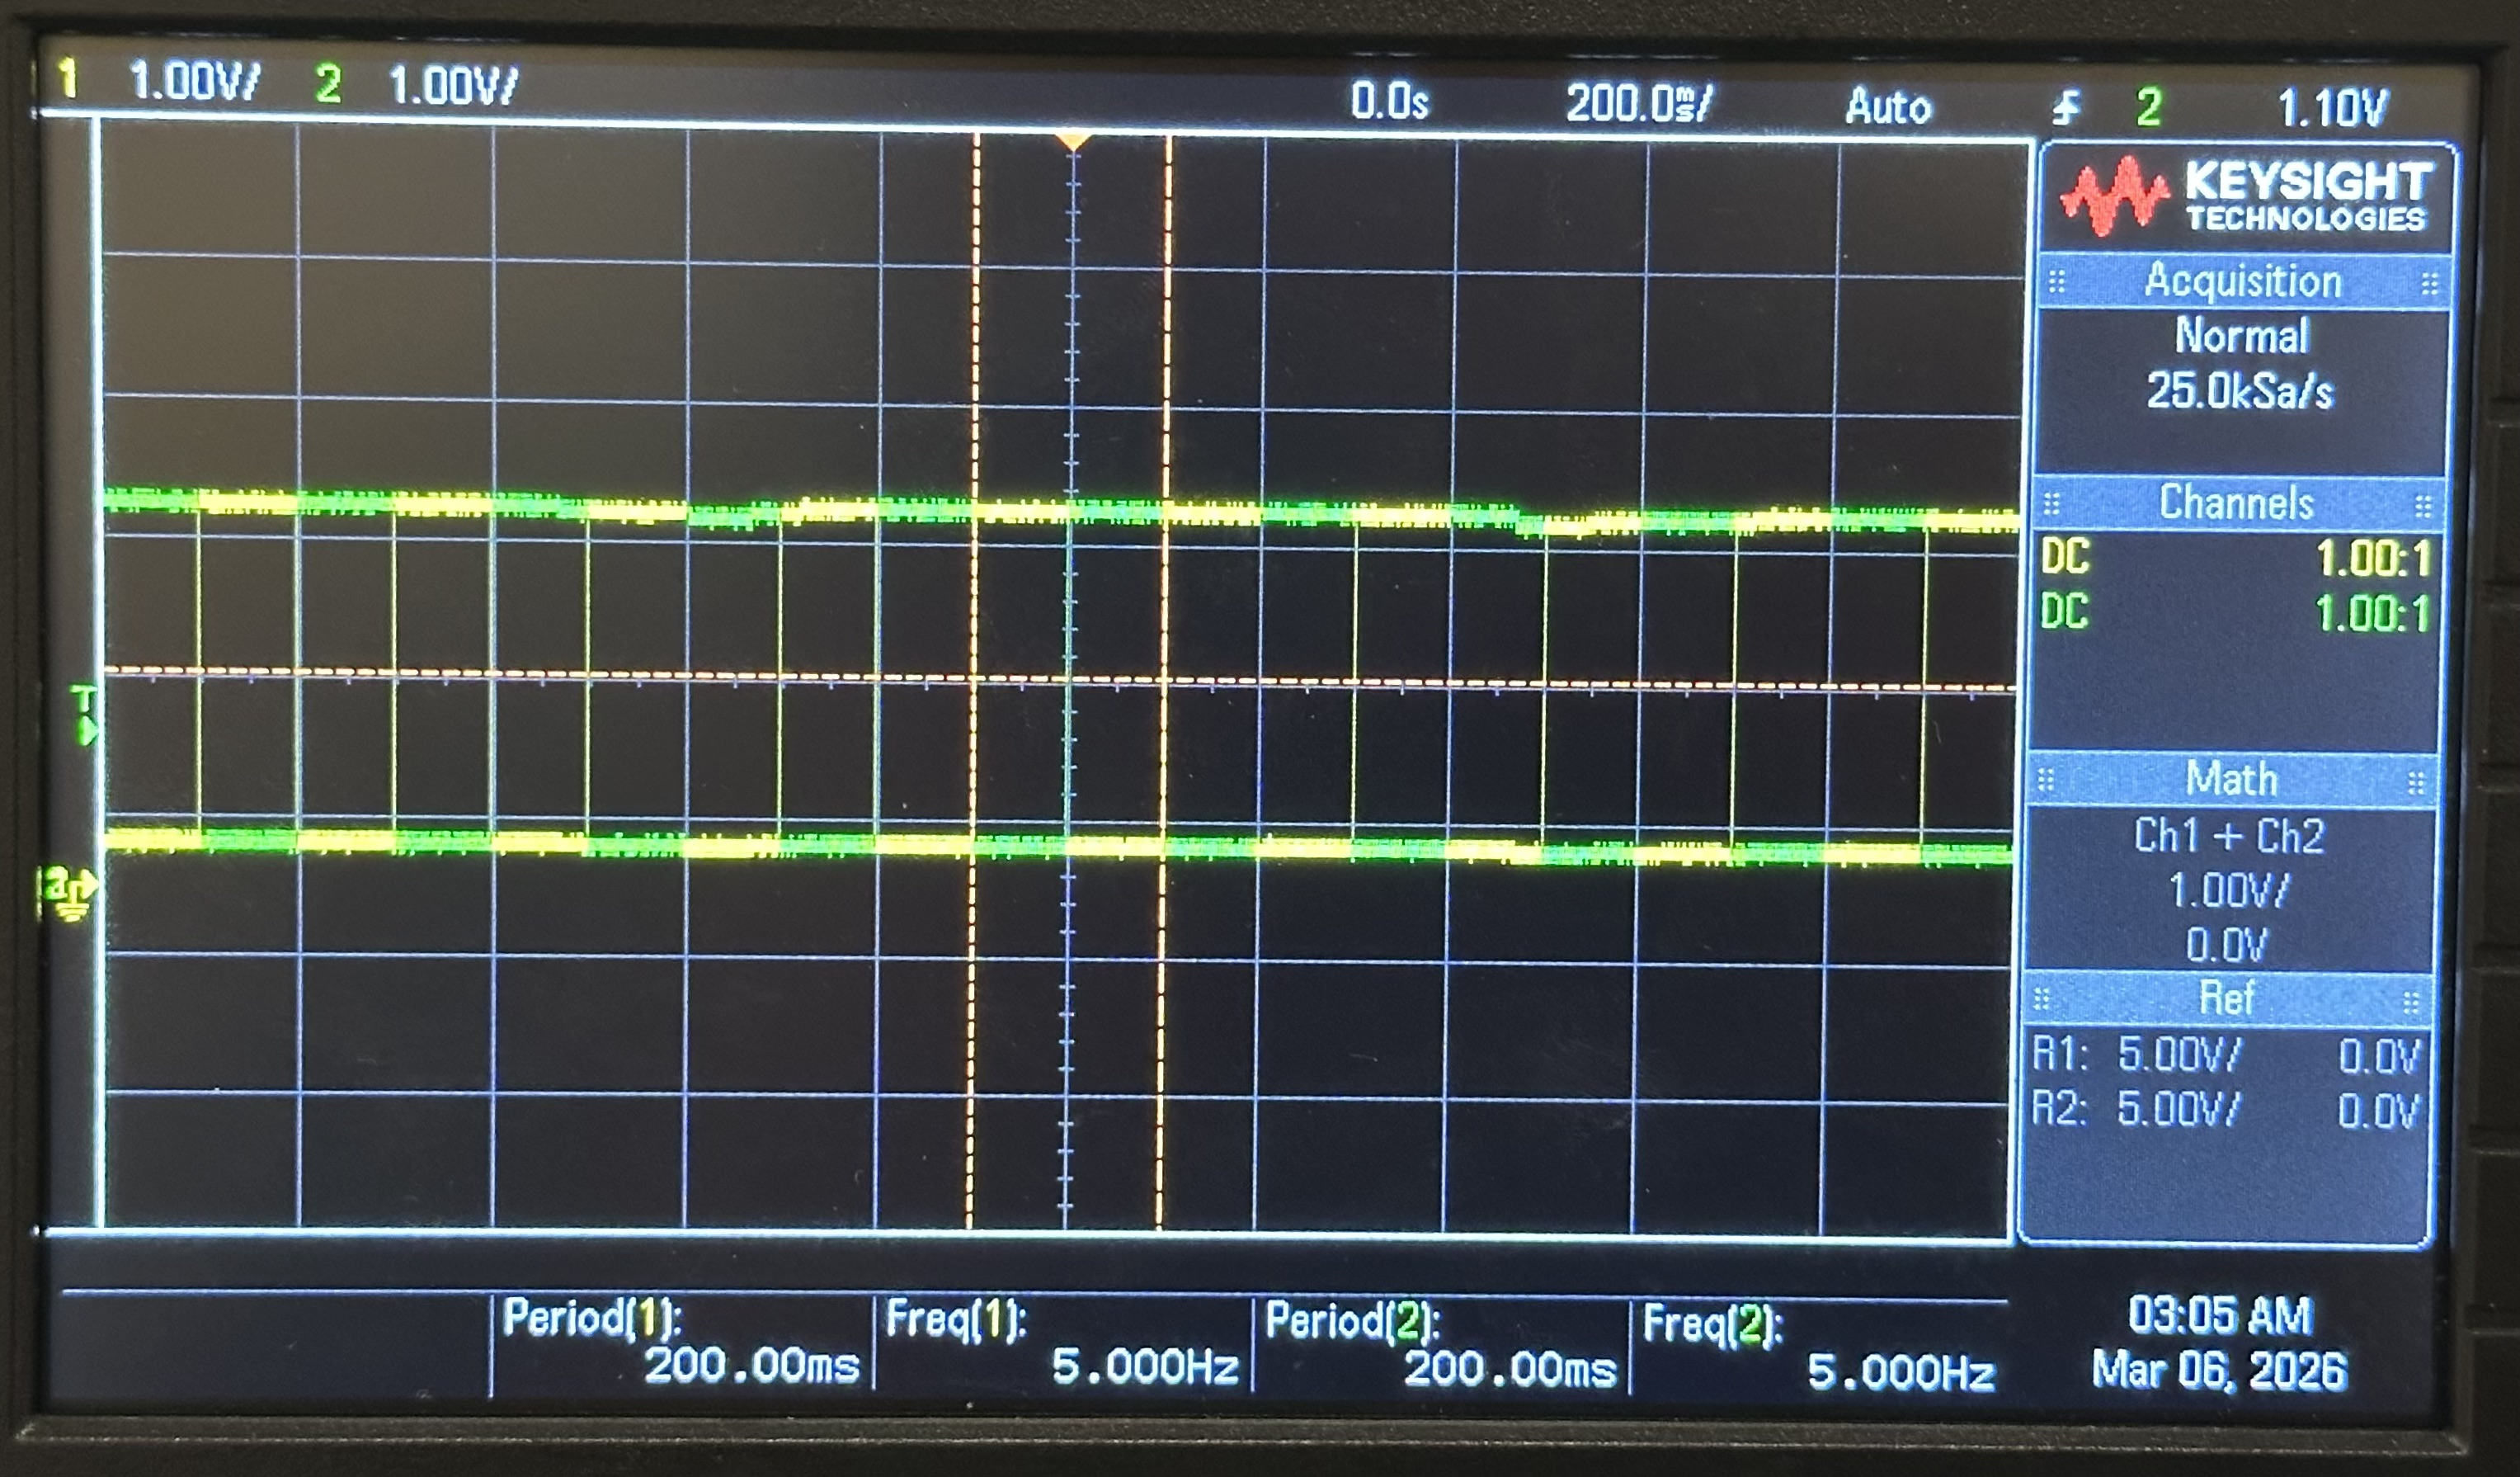

In [6]:
from IPython.display import Image, display

display(Image("5Hz.jpeg"))   # fill in file name

In [11]:
import pandas as pd

scope_5 = pd.DataFrame({
    "Condition": ["Action timing (5 Hz)"],
    "Measured Period (ms)": [200.0],    
    "Nominal Period (ms)":  [200.0],
    "Measured Frequency (Hz)": [5.0],  
    "Nominal Frequency (Hz)":  [5.0],
    "Resolution (ms)":      [0.04]    
})

scope_5["Half Resolution (ms)"] = scope_5["Resolution (ms)"] / 2

scope_5["95% CI Period (ms)"] = scope_5.apply(
    lambda row: (
        round(row["Measured Period (ms)"] - row["Half Resolution (ms)"], 3),
        round(row["Measured Period (ms)"] + row["Half Resolution (ms)"], 3)
    ),
    axis=1
)

scope_5["95% CI Frequency (Hz)"] = scope_5.apply(
    lambda row: (
        round(1000 / (row["Measured Period (ms)"] + row["Half Resolution (ms)"]), 4),
        round(1000 / (row["Measured Period (ms)"] - row["Half Resolution (ms)"]), 4)
    ),
    axis=1
)

scope_5["Error vs Nominal Period (ms)"] = (
    scope_5["Measured Period (ms)"] - scope_5["Nominal Period (ms)"]
)

scope_5["Error vs Nominal Frequency (Hz)"] = (
    scope_5["Measured Frequency (Hz)"] - scope_5["Nominal Frequency (Hz)"]
)

scope_5

,Condition,Measured Period (ms),Nominal Period (ms),Measured Frequency (Hz),Nominal Frequency (Hz),Resolution (ms),Half Resolution (ms),95% CI Period (ms),95% CI Frequency (Hz),Error vs Nominal Period (ms),Error vs Nominal Frequency (Hz)
0,Action timing (5 Hz),200.0,200.0,5.0,5.0,0.04,0.02,"(199.98, 200.02)","(4.9995, 5.0005)",0.0,0.0


## Discussion

The measured action LED frequencies obtained from the logging analysis closely matched their nominal specifications. Mean frequencies were approximately 1 Hz, 2 Hz, and 5 Hz for the minimum, default, and maximum operating conditions, respectively. These results indicate that the timing behavior of the action LEDs remained consistent with the intended design after refactoring the code to use kernel events for button handling.

As in the previous timer and thread testing analyses, repeated logging measurements produced identical values for many samples, resulting in a sample standard deviation of zero. This does not indicate perfect physical timing precision but instead reflects the finite resolution of the timestamp source. Because the elapsed time measurements are quantized to the system clock tick, the true timing uncertainty is limited by the tick resolution. Accordingly, the 95% confidence interval was estimated as plus or minus half of one system tick in the period domain.

Oscilloscope measurements independently confirmed the logging-based analysis. The measured signal periods and corresponding frequencies were consistent with the values calculated from the logging data and aligned closely with the nominal specifications. Any small differences between measured and nominal values are attributable to timer quantization and measurement resolution rather than instability in the LED timing implementation.

Overall, the results confirm that the refactoring of the button handling logic to use kernel events did not affect the timing behavior of the action LEDs. The LEDs continued to toggle at the correct frequencies across all tested operating conditions, demonstrating that the kernel event–based implementation preserves the timing accuracy of the original design.